# STAGE B3 — decorrelated 선형 멤버 + 4모델 블렌드

> **질문:** "GBDT와 충분히 다르게 틀리는 모델이 존재하는가?" 3 GBDT는 Spearman 0.99로 거의 동일 → 남은 레버 = **다른 계열(선형)**.
>
> **핵심:** 순진한 로지스틱은 약하다. 그래서 ① **fold-내부 타깃인코딩**(신호 있는 범주형), ② **비선형 기저**(난자수², 트리가 공짜로 얻는 것), ③ **명시적 상호작용**(H3/H5 — 트리엔 redundant였지만 선형엔 NOT)으로 선형을 무장시킨다.
>
> **게이트**
> - **G0** 사전점검: 기존 3트리 블렌드 Δ를 **페어드 부트스트랩**(95% CI가 0 넘는지).
> - **G1** decorrelation: `Spearman(lr, 각 GBDT) ≤ ~0.95` 면 블렌딩 가치.
> - **G2** 채택: 4모델 힐클라이밍 블렌드 **멀티시드** Δ>std **AND** LB 재현. lr 가중치 ~0 = "너무 약함"(네거티브도 답).
>
> **누수 요건:** 트리와 **동일 fold**(seed 42), TE/대치/스케일/`C`는 **fold-train만** fit, test 적용만.
>
> ⚠️ 무거움(4모델). 처음엔 `FAST=True`로 방향. `RUN_MULTISEED`는 확정 단계에서만.

## 1. 셋업

In [1]:
import re, os, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import xgboost as xgb
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",200)
def kfont():
    try:
        import koreanize_matplotlib; return "koreanize_matplotlib"
    except Exception: pass
    from matplotlib import font_manager
    for c in ["NanumGothic","Malgun Gothic","AppleGothic"]:
        if any(c in f.name for f in font_manager.fontManager.ttflist): matplotlib.rcParams["font.family"]=c; return c
    matplotlib.rcParams["axes.unicode_minus"]=False; return None
print("폰트:",kfont() or "미설정")

폰트: 미설정


## 2. 데이터 + 설정

In [2]:
csvs=sorted(glob.glob("/kaggle/input/**/*.csv",recursive=True)) or sorted(glob.glob("**/*.csv",recursive=True))
def pick(*ks):
    for p in csvs:
        if all(k in os.path.basename(p).lower() for k in ks): return p
train=pd.read_csv(pick("train") or csvs[0]); test=pd.read_csv(pick("test"))
sp=pick("sample") or pick("submission"); sample_sub=pd.read_csv(sp) if sp and "test" not in os.path.basename(sp).lower() else None
print("train",train.shape,"| test",test.shape)

SEED=42; N_SPLITS=5
FAST=False              # True: 3fold·짧은 라운드로 방향. 확정 시 False
RUN_MULTISEED=False    # G2 멀티시드(매우 무거움). seed42+LB 먼저 보고 켜기
TE_M=20                # 타깃인코딩 smoothing
C_GRID=[0.1,0.5,1.0]   # 로지스틱 C 가벼운 탐색
INCLUDE_CLINIC_TE=False  # 시술 시기 코드(약함) TE 포함 여부
if FAST: N_SPLITS=3
print(f"FAST={FAST} | SEED={SEED} | N_SPLITS={N_SPLITS} | RUN_MULTISEED={RUN_MULTISEED}")

train (256351, 69) | test (90067, 68)
FAST=False | SEED=42 | N_SPLITS=5 | RUN_MULTISEED=False


## 3. 컬럼/매핑 정의

In [3]:
TARGET="임신 성공 여부"; ID_COL="ID"; CLINIC_COL="시술 시기 코드"
COL_PROC="특정 시술 유형"; COL_RSN="배아 생성 주요 이유"
NUMERIC_COLS=["임신 시도 또는 마지막 임신 경과 연수","총 생성 배아 수","미세주입된 난자 수",
 "미세주입에서 생성된 배아 수","이식된 배아 수","미세주입 배아 이식 수","저장된 배아 수",
 "미세주입 후 저장된 배아 수","해동된 배아 수","해동 난자 수","수집된 신선 난자 수",
 "저장된 신선 난자 수","혼합된 난자 수","파트너 정자와 혼합된 난자 수","기증자 정자와 혼합된 난자 수",
 "난자 채취 경과일","난자 해동 경과일","난자 혼합 경과일","배아 이식 경과일","배아 해동 경과일"]
ORDINAL_COUNT_COLS=["총 시술 횟수","클리닉 내 총 시술 횟수","IVF 시술 횟수","DI 시술 횟수",
 "총 임신 횟수","IVF 임신 횟수","DI 임신 횟수","총 출산 횟수","IVF 출산 횟수","DI 출산 횟수"]
NOMINAL_COLS=["시술 시기 코드","시술 유형","배란 유도 유형","난자 출처","정자 출처"]
BINARY_CAUSE=["배란 자극 여부","단일 배아 이식 여부","남성 주 불임 원인","남성 부 불임 원인",
 "여성 주 불임 원인","여성 부 불임 원인","부부 주 불임 원인","부부 부 불임 원인","불명확 불임 원인",
 "불임 원인 - 난관 질환","불임 원인 - 남성 요인","불임 원인 - 배란 장애","불임 원인 - 여성 요인",
 "불임 원인 - 자궁경부 문제","불임 원인 - 자궁내막증","불임 원인 - 정자 농도","불임 원인 - 정자 면역학적 요인",
 "불임 원인 - 정자 운동성","불임 원인 - 정자 형태","동결 배아 사용 여부","신선 배아 사용 여부","기증 배아 사용 여부"]
MALE_COLS=["남성 주 불임 원인","불임 원인 - 남성 요인","불임 원인 - 정자 농도","불임 원인 - 정자 운동성","불임 원인 - 정자 형태"]
COUNT_MAP={"0회":0,"1회":1,"2회":2,"3회":3,"4회":4,"5회":5,"6회 이상":6}
AGE_T={"만18-34세":0,"만35-37세":1,"만38-39세":2,"만40-42세":3,"만43-44세":4,"만45-50세":5,"알 수 없음":-1}
AGE_D={"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1}
AGE_MAPS={"시술 당시 나이":AGE_T,"난자 기증자 나이":AGE_D,"정자 기증자 나이":AGE_D}
TE_COLS=["배아 생성 주요 이유","정자 출처","난자 출처"]+(["시술 시기 코드"] if INCLUDE_CLINIC_TE else [])
_tp=lambda s: [] if pd.isna(s) else [t.strip() for t in re.split(r"[/:]",str(s)) if t.strip()]
y=train[TARGET].astype(int).values
folds=list(StratifiedKFold(N_SPLITS,shuffle=True,random_state=SEED).split(train,y))
print("folds:",N_SPLITS,"| TE_COLS:",TE_COLS)

folds: 5 | TE_COLS: ['배아 생성 주요 이유', '정자 출처', '난자 출처']


## 4. 3 GBDT OOF (이전 노트북 출력 있으면 로드, 없으면 재학습)

이전 B→C1 노트북의 `oof_predictions.csv`/`test_predictions.csv`를 **Add Input**으로 붙여두면 재학습 없이 로드(빠름). 없으면 동일 fold로 재학습. *(반드시 seed 42 동일 fold여야 정렬됨)*

In [4]:
def fit_tree(tr):
    st={}; ig={TARGET,ID_COL}
    st["dead"]=[c for c in tr.columns if c not in ig and tr[c].nunique(dropna=True)<=1]
    st["sparse"]=[c for c in tr.columns if c not in ig and c not in st["dead"] and tr[c].isna().mean()>0.98]
    st["label_cats"]={c:pd.Index(tr[c].astype("category").cat.categories) for c in NOMINAL_COLS if c in tr}
    st["proc_vocab"]=sorted({t for L in tr[COL_PROC].apply(_tp) for t in L})
    return st
def tf_tree(df,st):
    df=df.copy()
    if TARGET in df: df=df.drop(columns=[TARGET])
    df["is_DI"]=(df["시술 유형"]=="DI").astype(int)
    df=df.drop(columns=[c for c in st["dead"] if c in df.columns])
    for c in st["sparse"]:
        if c in df: df[f"{c}_있음"]=df[c].notna().astype(int); df=df.drop(columns=[c])
    for c in ORDINAL_COUNT_COLS:
        if c in df: df[c]=df[c].map(COUNT_MAP)
    for c,m in AGE_MAPS.items():
        if c in df: df[c]=df[c].map(m)
    cats=[]
    for c,cc in st["label_cats"].items():
        if c in df: df[c]=pd.Categorical(df[c],categories=cc).codes.astype("int32"); cats.append(c)
    ts=df[COL_PROC].apply(_tp)
    for v in st["proc_vocab"]: df[f"proc_{v}"]=ts.apply(lambda L,v=v:int(v in L))
    df=df.drop(columns=[COL_PROC])
    if COL_RSN in df: df=df.drop(columns=[COL_RSN])
    df=df.drop(columns=[c for c in [ID_COL] if c in df.columns])
    obj=[c for c in df.columns if df[c].dtype==object]
    if obj: df=df.drop(columns=obj)
    for c in cats: df[c]=df[c].fillna(-1).astype("int32")
    return df,[c for c in cats if c in df.columns]

def trees_oof(train,test,folds,fast,seed=42):
    st=fit_tree(train); Xtr,cats=tf_tree(train,st); Xte,_=tf_tree(test,st)
    Xte=Xte.reindex(columns=Xtr.columns)
    for c in cats: Xte[c]=Xte[c].fillna(-1).astype("int32")
    yy=train[TARGET].astype(int).values
    oof={m:np.zeros(len(train)) for m in ["lgb","cat","xgb"]}; tst={m:np.zeros(len(test)) for m in ["lgb","cat","xgb"]}
    nr=250 if fast else 3000; stop=40 if fast else 100; n=len(folds)
    for k,(tri,vai) in enumerate(folds):
        Xt,Xv=Xtr.iloc[tri],Xtr.iloc[vai]; yt=yy[tri]
        d=lgb.Dataset(Xt,yt,categorical_feature=cats or "auto"); dv=lgb.Dataset(Xv,yy[vai],reference=d)
        lm=lgb.train(dict(objective="binary",metric="auc",learning_rate=0.05,num_leaves=63,
                          feature_fraction=0.8,bagging_fraction=0.8,bagging_freq=1,min_child_samples=50,verbose=-1,seed=seed),
                     d,num_boost_round=nr,valid_sets=[dv],callbacks=[lgb.early_stopping(stop,verbose=False),lgb.log_evaluation(0)])
        oof["lgb"][vai]=lm.predict(Xv); tst["lgb"]+=lm.predict(Xte)/n
        cm=CatBoostClassifier(iterations=nr,learning_rate=0.05,depth=6,verbose=0,random_seed=seed,early_stopping_rounds=stop)
        cm.fit(Pool(Xt,yt,cat_features=cats),eval_set=Pool(Xv,yy[vai],cat_features=cats))
        oof["cat"][vai]=cm.predict_proba(Xv)[:,1]; tst["cat"]+=cm.predict_proba(Xte)[:,1]/n
        xm=xgb.XGBClassifier(n_estimators=nr,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,
                             tree_method="hist",eval_metric="auc",early_stopping_rounds=stop,random_state=seed)
        xm.fit(Xt,yt,eval_set=[(Xv,yy[vai])],verbose=False)
        oof["xgb"][vai]=xm.predict_proba(Xv)[:,1]; tst["xgb"]+=xm.predict_proba(Xte)[:,1]/n
        print(f"  tree fold{k} done")
    return oof,tst

def get_tree_oof(train,test,folds,fast):
    of=(glob.glob("/kaggle/input/**/oof_predictions.csv",recursive=True)+glob.glob("oof_predictions.csv")+glob.glob("/kaggle/working/oof_predictions.csv"))
    tf=(glob.glob("/kaggle/input/**/test_predictions.csv",recursive=True)+glob.glob("test_predictions.csv")+glob.glob("/kaggle/working/test_predictions.csv"))
    if of and tf:
        od=pd.read_csv(of[0]); td=pd.read_csv(tf[0])
        if len(od)==len(train) and len(td)==len(test) and all(f"oof_{m}" in od.columns for m in ["lgb","cat","xgb"]):
            print("[3트리 OOF 로드]",of[0])
            return {m:od[f"oof_{m}"].values for m in ["lgb","cat","xgb"]}, {m:td[f"test_{m}"].values for m in ["lgb","cat","xgb"]}
    print("[3트리 OOF 재학습] (이전 출력을 Add Input하면 다음부턴 로드)")
    return trees_oof(train,test,folds,fast)

oof,tst=get_tree_oof(train,test,folds,FAST)
single_tree={m:roc_auc_score(y,oof[m]) for m in oof}
print("3트리 단일 AUC:",{k:round(v,5) for k,v in single_tree.items()})

[3트리 OOF 재학습] (이전 출력을 Add Input하면 다음부턴 로드)
  tree fold0 done
  tree fold1 done
  tree fold2 done
  tree fold3 done
  tree fold4 done
3트리 단일 AUC: {'lgb': np.float64(0.73944), 'cat': np.float64(0.73963), 'xgb': np.float64(0.73959)}


## 5. G0 — 3트리 블렌드 Δ 페어드 부트스트랩 (사전점검)

In [5]:
def hill(oofd,yy,n_iter=80):
    names=list(oofd); sing={n:roc_auc_score(yy,oofd[n]) for n in names}; b0=max(sing,key=sing.get)
    ens=[b0]; s=oofd[b0].copy(); snaps=[(list(ens),roc_auc_score(yy,s/len(ens)))]
    for _ in range(n_iter):
        cb,ca=None,-1
        for n in names:
            a=roc_auc_score(yy,(s+oofd[n])/(len(ens)+1))
            if a>ca: ca,cb=a,n
        ens.append(cb); s=s+oofd[cb]; snaps.append((list(ens),roc_auc_score(yy,s/len(ens))))
    be,ba=max(snaps,key=lambda t:t[1])
    from collections import Counter; c=Counter(be)
    return {n:c.get(n,0)/len(be) for n in names},ba,b0,sing

w3,blend3,best3,_=hill(oof,y)
b3=sum(w3[m]*oof[m] for m in w3)
rng=np.random.default_rng(0); idx=np.arange(len(y)); ds=[]
for _ in range(1000):
    s=rng.choice(idx,len(idx),replace=True)
    ds.append(roc_auc_score(y[s],b3[s])-roc_auc_score(y[s],oof[best3][s]))
lo,hi=np.percentile(ds,[2.5,97.5])
print(f"3트리 블렌드 가중치:{{}}".format({k:round(v,2) for k,v in w3.items()}))
print(f"블렌드 Δ vs 최강단일({best3}): 평균 {np.mean(ds):+.5f} | 95%CI [{lo:+.5f}, {hi:+.5f}]")
print("→ CI가 0을 포함하면 3트리 앙상블 전제부터 약함(0 불포함이면 견고)")

3트리 블렌드 가중치:{'lgb': 0.31, 'cat': 0.42, 'xgb': 0.27}
블렌드 Δ vs 최강단일(cat): 평균 +0.00048 | 95%CI [+0.00029, +0.00067]
→ CI가 0을 포함하면 3트리 앙상블 전제부터 약함(0 불포함이면 견고)


## 6. 선형 멤버 — fold-내부 TE + 스케일 + 상호작용

타깃인코딩/대치/스케일/`C` 전부 **fold-train만** fit. 비선형 기저(난자수²)·상호작용(H3 곱항, H5 부호반전)을 명시해 선형을 무장.

In [6]:
class TE:
    def __init__(self,m=20): self.m=m
    def fit(self,s,yy):
        self.g=float(np.mean(yy)); d=pd.DataFrame({"c":s.astype(str).fillna("NA").values,"y":yy})
        a=d.groupby("c")["y"].agg(["sum","count"]); self.map=(a["sum"]+self.m*self.g)/(a["count"]+self.m); return self
    def transform(self,s): return s.astype(str).fillna("NA").map(self.map).fillna(self.g).values

def fit_lr_g(train):
    g={}; ig={TARGET,ID_COL}
    g["dead"]=[c for c in train.columns if c not in ig and train[c].nunique(dropna=True)<=1]
    g["sparse"]=[c for c in train.columns if c not in ig and c not in g["dead"] and train[c].isna().mean()>0.98]
    g["proc_vocab"]=sorted({t for L in train[COL_PROC].apply(_tp) for t in L})
    g["num"]=[c for c in NUMERIC_COLS if c in train.columns and c not in g["dead"] and c not in g["sparse"]]
    g["bin"]=[c for c in BINARY_CAUSE if c in train.columns and c not in g["dead"]]
    return g

def lr_base(df,g):
    icsi=df[COL_PROC].fillna("").str.contains("ICSI")
    male=df[[c for c in MALE_COLS if c in df.columns]].fillna(0).astype(int).max(axis=1).astype(bool)
    don=(df["난자 출처"]=="기증 제공").astype(int)
    eff=np.where(don==1, df["난자 기증자 나이"].map(AGE_D), df["시술 당시 나이"].map(AGE_T)).astype(float)
    num={}
    for c in g["num"]: num[c]=df[c].astype(float)
    for c in ORDINAL_COUNT_COLS:
        if c in df: num[c]=df[c].map(COUNT_MAP).astype(float)
    for c,m in AGE_MAPS.items():
        if c in df: num[c]=df[c].map(m).astype(float)
    eggs=df["수집된 신선 난자 수"].astype(float)
    num["eggs2"]=eggs**2; num["유효나이"]=eff; num["H3_기증x유효나이"]=don.values*np.nan_to_num(eff)
    NUM=pd.DataFrame(num,index=df.index)
    b={}
    for c in g["bin"]: b[c]=df[c].fillna(0).astype(int)
    ts=df[COL_PROC].apply(_tp)
    for v in g["proc_vocab"]: b[f"proc_{v}"]=ts.apply(lambda L,v=v:int(v in L))
    for c in g["sparse"]:
        if c in df: b[f"{c}_있음"]=df[c].notna().astype(int)
    b["is_DI"]=(df["시술 유형"]=="DI").astype(int); b["난자출처_기증"]=don
    b["ICSI_남성요인"]=(icsi&male).astype(int); b["ICSI_무남성요인"]=(icsi&~male).astype(int)
    return NUM, pd.DataFrame(b,index=df.index)

def lr_oof(train,test,folds,C,m,te_cols):
    yy=train[TARGET].astype(int).values; g=fit_lr_g(train)
    oof=np.zeros(len(train)); tst=np.zeros(len(test)); n=len(folds); coef=None; names=None
    for tri,vai in folds:
        Ntr,Btr=lr_base(train.iloc[tri],g); Nva,Bva=lr_base(train.iloc[vai],g); Nte,Bte=lr_base(test,g)
        for c in te_cols:
            e=TE(m).fit(train[c].iloc[tri],yy[tri])
            Ntr["te_"+c]=e.transform(train[c].iloc[tri]); Nva["te_"+c]=e.transform(train[c].iloc[vai]); Nte["te_"+c]=e.transform(test[c])
        Nva=Nva.reindex(columns=Ntr.columns); Nte=Nte.reindex(columns=Ntr.columns)
        Bva=Bva.reindex(columns=Btr.columns,fill_value=0); Bte=Bte.reindex(columns=Btr.columns,fill_value=0)
        med=Ntr.median(); Ntr=Ntr.fillna(med); Nva=Nva.fillna(med); Nte=Nte.fillna(med)
        sc=StandardScaler().fit(Ntr.values)
        Xt=np.hstack([sc.transform(Ntr.values),Btr.values]); Xv=np.hstack([sc.transform(Nva.values),Bva.values]); Xe=np.hstack([sc.transform(Nte.values),Bte.values])
        lr=LogisticRegression(C=C,max_iter=2000).fit(Xt,yy[tri])
        oof[vai]=lr.predict_proba(Xv)[:,1]; tst+=lr.predict_proba(Xe)[:,1]/n
        names=list(Ntr.columns)+list(Btr.columns); coef=lr.coef_[0] if coef is None else coef+lr.coef_[0]
    return oof,tst,dict(zip(names,coef/n))

## 7. 선형 멤버 학습 (C 가벼운 탐색)

In [7]:
best=(None,-1,None,None)
for C in C_GRID:
    o,t,cf=lr_oof(train,test,folds,C,TE_M,TE_COLS)
    a=roc_auc_score(y,o); print(f"  C={C}: OOF AUC={a:.5f}")
    if a>best[1]: best=(C,a,o,t); coefs=cf
C_best,auc_lr,oof_lr,test_lr=best
print(f"\n★ 선형 멤버 best C={C_best} | OOF AUC={auc_lr:.5f}")

  C=0.1: OOF AUC=0.71904
  C=0.5: OOF AUC=0.71903
  C=1.0: OOF AUC=0.71903

★ 선형 멤버 best C=0.1 | OOF AUC=0.71904


## 8. G1 — decorrelation (4모델 Spearman)

Spearman(4모델):
        lgb    cat    xgb     lr
lgb  1.000  0.988  0.992  0.890
cat  0.988  1.000  0.990  0.899
xgb  0.992  0.990  1.000  0.895
lr   0.890  0.899  0.895  1.000

lr vs 트리 최대 Spearman = 0.899  →  decorrelated (블렌딩 가치 있음)


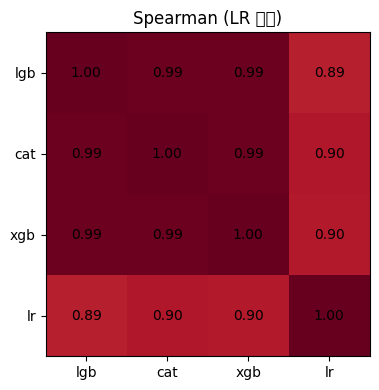

In [8]:
all4={**oof,"lr":oof_lr}
S=pd.DataFrame(all4).corr(method="spearman")
print("Spearman(4모델):\n",S.round(3).to_string())
lr_max=max(S.loc["lr",m] for m in ["lgb","cat","xgb"])
print(f"\nlr vs 트리 최대 Spearman = {lr_max:.3f}  →  {'decorrelated (블렌딩 가치 있음)' if lr_max<=0.95 else '트리와 사실상 중복(멤버로 약함)'}")
fig,ax=plt.subplots(figsize=(5,4)); im=ax.imshow(S,cmap='RdBu_r',vmin=0,vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(S.columns); ax.set_yticks(range(4)); ax.set_yticklabels(S.columns)
for i in range(4):
    for j in range(4): ax.text(j,i,f"{S.iloc[i,j]:.2f}",ha='center',va='center')
plt.title("Spearman (LR 포함)"); plt.tight_layout(); plt.show()

## 9. G2 — 4모델 힐클라이밍 블렌드 (seed 42)

In [9]:
single4={**single_tree,"lr":auc_lr}
w4,blend4,best4,_=hill(all4,y)
print("4모델 블렌드 가중치:",{k:round(v,3) for k,v in w4.items()})
print(f"  블렌드 OOF={blend4:.5f} | 최강단일({best4})={single4[best4]:.5f} | Δ={blend4-single4[best4]:+.5f}")
lrw=w4["lr"]
print(f"  lr 가중치={lrw:.3f}  →  {'기여함' if lrw>0.02 else '≈0: 선형 멤버 너무 약함(네거티브 결과)'}")
print(f"  (참고) 3트리 블렌드 OOF={blend3:.5f} → 4모델이 {blend4-blend3:+.5f}")

4모델 블렌드 가중치: {'lgb': 0.303, 'cat': 0.382, 'xgb': 0.263, 'lr': 0.053}
  블렌드 OOF=0.74017 | 최강단일(cat)=0.73963 | Δ=+0.00054
  lr 가중치=0.053  →  기여함
  (참고) 3트리 블렌드 OOF=0.74011 → 4모델이 +0.00006


## 10. (선택) G2 멀티시드 — `RUN_MULTISEED=True`일 때만

4모델을 seed (42,7,2024)로 재학습해 블렌드 mean±std. **매우 무거움.** seed42+LB 먼저 보고 확정 단계에서 켜기.

In [10]:
if RUN_MULTISEED:
    rows=[]
    for s in (42,7,2024):
        fd=list(StratifiedKFold(N_SPLITS,shuffle=True,random_state=s).split(train,y))
        o3,_=trees_oof(train,test,fd,FAST,seed=s)
        olr,_,_=lr_oof(train,test,fd,C_best,TE_M,TE_COLS)
        a4={**o3,"lr":olr}; _,bl,b0,sg=hill(a4,y)
        rows.append({"seed":s,"blend":round(bl,5),"best_single":round(sg[b0],5),"Δ":round(bl-sg[b0],5)})
        print(f"  seed{s}: blend={bl:.5f} Δ={bl-sg[b0]:+.5f}")
    r=pd.DataFrame(rows)
    print(f"\n블렌드 Δ mean±std = {r['Δ'].mean():+.5f} ± {r['Δ'].std():.5f}")
    print("→ Δmean > std 면 채택 후보(+LB 재현 확인)")
else:
    print("RUN_MULTISEED=False — seed42 결과 + LB로 먼저 판단. 확정 시 True로.")

RUN_MULTISEED=False — seed42 결과 + LB로 먼저 판단. 확정 시 True로.


## 11. 산출물 — OOF 갱신 + 제출

In [11]:
# oof_predictions.csv 에 oof_lr 추가(스태킹 C2 재사용) — 길이 다른 기존 파일이면 새로 생성
od=None
if os.path.exists("oof_predictions.csv"):
    _tmp=pd.read_csv("oof_predictions.csv")
    if len(_tmp)==len(oof_lr): od=_tmp
if od is None:
    od=pd.DataFrame({**{f"oof_{m}":oof[m] for m in oof},"y":y})
od["oof_lr"]=oof_lr; od.to_csv("oof_predictions.csv",index=False)

def write_sub(pred,name):
    s=sample_sub.copy() if sample_sub is not None else pd.DataFrame({ID_COL:test[ID_COL].values})
    pc=[c for c in s.columns if c!=ID_COL]; pc=pc[0] if pc else "probability"
    pm=dict(zip(test[ID_COL].values,pred))
    if ID_COL in s.columns: s[pc]=s[ID_COL].map(pm)
    else: s[ID_COL]=test[ID_COL].values; s[pc]=pred
    s.to_csv(name,index=False); return s,pc

all_test={**tst,"lr":test_lr}
test_blend4=sum(w4[m]*all_test[m] for m in w4)
sub,pc=write_sub(test_blend4,"submission_blend4.csv")
write_sub(test_lr,"submission_lr.csv")
print("submission_blend4.csv:",sub.shape,"| 결측",int(sub[pc].isna().sum()))
print("submission_lr.csv 저장(LR 단독 LB A/B용) | oof_predictions.csv에 oof_lr 추가")
sub.head()

submission_blend4.csv: (90067, 2) | 결측 0
submission_lr.csv 저장(LR 단독 LB A/B용) | oof_predictions.csv에 oof_lr 추가


,ID,probability
0,TEST_00000,0.005032
1,TEST_00001,0.008944
2,TEST_00002,0.157256
3,TEST_00003,0.104508
4,TEST_00004,0.507490


## 12. (관찰) 선형 멤버의 H3/H5 상호작용 계수

In [12]:
watch=["H3_기증x유효나이","ICSI_남성요인","ICSI_무남성요인","유효나이","eggs2"]
print("선형 멤버 계수(평균):")
for k in watch:
    if k in coefs: print(f"  {k:18}: {float(coefs[k]):+.4f}")
top=sorted(coefs.items(),key=lambda kv:-abs(kv[1]))[:12]
print("\n|계수| 상위 12:")
for k,v in top: print(f"  {k:22}: {float(v):+.4f}")

선형 멤버 계수(평균):
  H3_기증x유효나이        : +0.2824
  ICSI_남성요인         : -0.0020
  ICSI_무남성요인        : -0.1039
  유효나이              : -0.5034
  eggs2             : -0.3467

|계수| 상위 12:
  이식된 배아 수              : +0.7193
  신선 배아 사용 여부           : -0.6986
  단일 배아 이식 여부           : +0.6718
  유효나이                  : -0.5034
  te_배아 생성 주요 이유        : +0.4338
  eggs2                 : -0.3467
  배아 이식 경과일             : +0.3256
  H3_기증x유효나이            : +0.2824
  proc_IVF              : -0.2418
  난자출처_기증               : -0.2362
  동결 배아 사용 여부           : +0.1834
  수집된 신선 난자 수           : +0.1595


## 13. 결정

- **G1 통과(Spearman ≤0.95) + G2 lr 가중치>0 + Δ>0 + LB 재현** → 선형 멤버 채택, `submission_blend4.csv` 제출.
- **lr 가중치 ≈0 또는 Δ가 LB에서 안 보임** → **명확한 네거티브**: "트리 아닌 모델로도 안 갈린다 = 천장 근접" 확증. 발표 자산 + D 튜닝/제출 정리로 전환.
- **H3/H5 계수가 선형에서 가중치 받음** → "그 가설엔 실재 신호가 있었고 트리가 자동 흡수했을 뿐" 입증(발표 서사).
- LB A/B: `submission_blend4.csv`(4모델) vs `submission.csv`(3모델, 0.74182) vs `submission_lr.csv`(LR 단독).

> ⚠️ FAST=True로 방향 → 확정 시 FAST=False + (필요시)RUN_MULTISEED=True. 무거우면 이전 노트북 출력을 Add Input해 3트리 재학습 생략.